# Imports, Primitives

In [ ]:
import math
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import tensorflow as tf
from google.colab import drive
from PIL import Image, ImageFont
from shapely.geometry import Point
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, losses, regularizers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau

drive.mount('/content/drive')
import os, time

ZIP_SRC  = "/content/drive/MyDrive/Deep Learning Project/GoogleStreetViewImagesNew.zip"
LOCAL_DIR = "/content/streetview_dataset"

if not os.path.exists(LOCAL_DIR):
    t0 = time.time()
    !cp "{ZIP_SRC}" /content/streetview_dataset.zip
    !unzip -q /content/streetview_dataset.zip -d {LOCAL_DIR}
    print(f"Staged in {time.time() - t0:.1f}s")

!ls {LOCAL_DIR} | head

Mounted at /content/drive
Staged in 50.9s
GoogleStreetViewImagesNew
__MACOSX


## Data Loading Function

In [ ]:
# Precursor Functions

###################
# I. Data loading #
###################
# Sources:
# Assignment I dataloading fn &
# https://medium.com/@kumudtraveldiaries/step-by-step-preprocessing-guide-for-images-in-both-cnn-and-dense-layer-pipelines-1994c3ad3e87

def dataloading(csv_path="/content/drive/MyDrive/Deep Learning Project/images_bra-2.csv",
                img_size=224,
                batch_size=32,
                preprocess_fn=None,
                ordinal=None):

    # 1. Load CSV
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=["income_group"]).reset_index(drop=True)

    df["full_path"] = df["file_path"].apply(
        lambda f: os.path.join("/content/streetview_dataset/", f)
    )
    df["loc_id"] = df["file_path"].apply(
        lambda f: os.path.basename(f).split("_h")[0]
    )

    before = len(df)
    df = df[df["full_path"].apply(os.path.exists)].reset_index(drop=True)
    print(f"Dropped {before - len(df)} missing files, {len(df)} remaining")


    # 4. Train / Val / Test split at location level
    locs = df["loc_id"].unique()
    np.random.seed(50)
    np.random.shuffle(locs)
    n_test = int(len(locs) * 0.15)
    n_val  = int(len(locs) * 0.15)
    test_locs  = locs[:n_test]
    val_locs   = locs[n_test:n_test + n_val]
    train_locs = locs[n_test + n_val:]

    train_df = df[df["loc_id"].isin(train_locs)]
    val_df   = df[df["loc_id"].isin(val_locs)]
    test_df  = df[df["loc_id"].isin(test_locs)]

    def to_ordinal(y, num_classes=3):
        out = np.zeros((len(y), num_classes - 1), dtype=np.float32)
        for i, label in enumerate(y):
            out[i, :label] = 1.0
        return out

    train_labels = train_df["income_group"].values.astype(np.int64)
    val_labels   = val_df["income_group"].values.astype(np.int64)
    test_labels  = test_df["income_group"].values.astype(np.int64)

    if ordinal:
        train_labels = to_ordinal(train_labels, num_classes=3)
        val_labels   = to_ordinal(val_labels,   num_classes=3)
        test_labels  = to_ordinal(test_labels,  num_classes=3)

    splits = {
        "train": (train_df["full_path"].values, train_labels),
        "val":   (val_df["full_path"].values,   val_labels),
        "test":  (test_df["full_path"].values,  test_labels),
    }

    for k, (p, l) in splits.items():
        print(f"{k}: {len(p)} images")

    # 5. Image loading function
    def load_image(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.image.resize(img, [img_size, img_size])
        img = tf.cast(img, tf.float32)
        if preprocess_fn:
            img = preprocess_fn(img)
        else:
            img = img / 255.0
        return img, label

    # 6. Build tf.data pipelines
    def make_dataset(file_paths, lbls, is_train=False):
        ds = tf.data.Dataset.from_tensor_slices((file_paths, lbls))
        ds = ds.cache()
        if is_train:
            ds = ds.shuffle(len(file_paths))
        ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds

    train_ds = make_dataset(*splits["train"], is_train=True)
    val_ds   = make_dataset(*splits["val"])
    test_ds  = make_dataset(*splits["test"])

    return train_ds, val_ds, test_ds

# EfficientNetV2S Backbone Multi-Heading Prediction (LSTM Fusion)

A shared EfficientNetV2S backbone processes each of the four cardinal heading views via a TimeDistributed wrapper, producing a sequence of per-view embeddings that is then fused by an LSTM, treating the 0° → 90° → 180° → 270° sweep as an ordered spatial sequence rather than an unordered bag of views.

## Architecture

    Input (4 × H × W × C)              ← 4 cardinal views per location
            ↓
    TimeDistributed(Augmentation)      ← per-view random transforms (train only)
            ↓
    TimeDistributed(EfficientNetV2S)   ← shared frozen backbone (~21M params)
            ↓
    TimeDistributed(GlobalAvgPool2D)   ← (batch, 4, 1280)
            ↓
    LSTM(256)                          ← sequential fusion over the 4 views
            ↓
    Dropout(0.4) → Dense(512, relu) → Dropout(0.3)
            ↓
    Dense(3, softmax)                  ← location-level class probabilities

In [ ]:


# Multi-view dataloading (fixed)
def dataloading_multiview(csv_path, img_size=384, batch_size=16, preprocess_fn=None):
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=["income_group"]).reset_index(drop=True)
    df["full_path"] = df["file_path"].apply(
        lambda f: os.path.join("/content/streetview_dataset/", f)
    )
    df["loc_id"] = df["file_path"].apply(
        lambda f: os.path.basename(f).split("_h")[0]
    )
    df["heading"] = df["file_path"].apply(
        lambda f: int(os.path.basename(f).split("_h")[1].replace(".jpg", ""))
    )

    # Filter missing files
    df = df[df["full_path"].apply(os.path.exists)].reset_index(drop=True)

    # Group by location — sort headings so view order is always 0,90,180,270
    grouped = (
        df.sort_values("heading")
          .groupby("loc_id")
          .agg(
              paths=("full_path", list),
              label=("income_group", "first")
          )
          .reset_index()
    )

    # Keep only locations with exactly 4 headings
    grouped = grouped[grouped["paths"].apply(len) == 4].reset_index(drop=True)
    print(f"Locations with all 4 headings: {len(grouped)}")

    # Location-level split (seed=50 — same as single-view runs)
    np.random.seed(50)
    loc_ids = grouped["loc_id"].values.copy()
    np.random.shuffle(loc_ids)
    n = len(loc_ids)
    train_ids = set(loc_ids[:int(0.70 * n)])
    val_ids   = set(loc_ids[int(0.70 * n):int(0.85 * n)])
    test_ids  = set(loc_ids[int(0.85 * n):])

    train_df = grouped[grouped["loc_id"].isin(train_ids)].reset_index(drop=True)
    val_df   = grouped[grouped["loc_id"].isin(val_ids)].reset_index(drop=True)
    test_df  = grouped[grouped["loc_id"].isin(test_ids)].reset_index(drop=True)

    print(f"Train locations: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"Train images: {len(train_df)*4} | Val: {len(val_df)*4} | Test: {len(test_df)*4}")

    def make_dataset(split_df, shuffle=False):
        paths_list = split_df["paths"].tolist()
        labels     = split_df["label"].values.astype(np.int32)

        def generator():
            for paths, label in zip(paths_list, labels):
                yield paths, label

        ds = tf.data.Dataset.from_generator(
            generator,
            output_signature=(
                tf.TensorSpec(shape=(4,), dtype=tf.string),
                tf.TensorSpec(shape=(),   dtype=tf.int32)
            )
        )

        def load_fn(paths, label):
            imgs = tf.map_fn(
                lambda p: preprocess_fn(
                    tf.cast(
                        tf.image.resize(
                            tf.image.decode_jpeg(tf.io.read_file(p), channels=3),
                            [img_size, img_size]
                        ), tf.float32
                    )
                ),
                paths,
                fn_output_signature=tf.TensorSpec(
                    shape=(img_size, img_size, 3), dtype=tf.float32
                )
            )
            return imgs, label   # (4, H, W, 3), scalar

        if shuffle:
            ds = ds.shuffle(buffer_size=len(split_df), seed=42)

        ds = (ds
              .map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(batch_size)
              .repeat()
              .prefetch(tf.data.AUTOTUNE))
        return ds

    train_ds = make_dataset(train_df, shuffle=True)
    val_ds   = make_dataset(val_df,   shuffle=False)
    test_ds  = make_dataset(test_df,  shuffle=False)


    steps = {
        "train" : math.ceil(len(train_df) / batch_size),
        "val"   : math.ceil(len(val_df)   / batch_size),
        "test"  : math.ceil(len(test_df)  / batch_size),
    }
    print(f"Steps — train: {steps['train']} | val: {steps['val']} | test: {steps['test']}")

    return train_ds, val_ds, test_ds, steps, train_df, val_df, test_df


IMG_SIZE   = 384
BATCH_SIZE = 16

train_ds, val_ds, test_ds, steps, train_df, val_df, test_df = dataloading_multiview(
    csv_path="/content/drive/MyDrive/Deep Learning Project/images_bra-3.csv",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    preprocess_fn=tf.keras.applications.efficientnet_v2.preprocess_input
)

image_batch, label_batch = next(iter(train_ds))
print("Image batch shape :", image_batch.shape)   # (16, 4, 384, 384, 3)
print("Label batch shape :", label_batch.shape)   # (16,)

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

# Shared EfficientNetV2S backbone
base_model = tf.keras.applications.EfficientNetV2S(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

gap = tf.keras.layers.GlobalAveragePooling2D(name="gap")


inputs = tf.keras.Input(shape=(4, IMG_SIZE, IMG_SIZE, 3), name="multiview_input")

x = tf.keras.layers.TimeDistributed(
        data_augmentation, name="td_augmentation"
    )(inputs)

x = tf.keras.layers.TimeDistributed(
        base_model, name="td_backbone"
    )(x, training=False)                          # (batch, 4, 12, 12, 1280)

x = tf.keras.layers.TimeDistributed(
        gap, name="td_gap"
    )(x)                                          # (batch, 4, 1280)

# ── LSTM fusion ────────────────────────────────────────────────────────────────
x = tf.keras.layers.LSTM(
        256,
        return_sequences=False,
        dropout=0.2,               # input dropout within LSTM
        recurrent_dropout=0.0,     # keep recurrent path clean for stability
        name="view_lstm"
    )(x)                                          # (batch, 256)

# Head
x = tf.keras.layers.Dropout(0.4, name="dropout_1")(x)
x = tf.keras.layers.Dense(
        512, activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name="dense_hidden"
    )(x)
x = tf.keras.layers.Dropout(0.3, name="dropout_2")(x)
outputs = tf.keras.layers.Dense(
            3, activation="softmax",
            kernel_regularizer=tf.keras.regularizers.l2(1e-4),
            name="predictions"
          )(x)

model = tf.keras.Model(inputs, outputs, name="EfficientNetV2S_LSTM_MultiView")
model.summary()

def make_callbacks(ckpt="best_efficientnetv2s_lstm.keras"):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=10,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=4,
            min_lr=1e-6, verbose=1
        ),
    ]

print("\n=== Phase 1: Feature Extraction (frozen backbone) ===")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=steps["train"],
    validation_steps=steps["val"],
    callbacks=make_callbacks(),
    verbose=1
)

print("\n=== Test Evaluation (Phase 1) ===")
loss_p1, acc_p1 = model.evaluate(test_ds, steps=steps["test"], verbose=1)
print(f"Test accuracy : {acc_p1:.4f}  |  Test loss : {loss_p1:.4f}")

print("\n=== Phase 2: Fine-Tuning (top 30% of backbone unfrozen) ===")

base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.70)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Freezing layers 0–{fine_tune_at} / {len(base_model.layers)}")
print(f"Trainable backbone layers: {trainable_count} / {len(base_model.layers)}")

total_steps = 30 * steps["train"]
cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=total_steps,
    alpha=1e-7,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_efficientnetv2s_lstm.keras",
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    steps_per_epoch=steps["train"],
    validation_steps=steps["val"],
    callbacks=callbacks_p2,
    verbose=1
)

print("\n=== Test Evaluation (Phase 2 — Fine-tuned) ===")
loss_p2, acc_p2 = model.evaluate(test_ds, steps=steps["test"], verbose=1)
print(f"Test accuracy : {acc_p2:.4f}  |  Test loss : {loss_p2:.4f}")
print(f"Single-view EfficientNetV2S baseline : 66.35%")
print(f"LSTM multi-view (Phase 2)            : {acc_p2*100:.2f}%")

Locations with all 4 headings: 5476
Train locations: 3833 | Val: 821 | Test: 822
Train images: 15332 | Val: 3284 | Test: 3288
Steps — train: 240 | val: 52 | test: 52
Image batch shape : (16, 4, 384, 384, 3)
Label batch shape : (16,)
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "EfficientNetV2S_LSTM_MultiView"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ multiview_input (InputLayer)    │ (None, 4, 384, 384, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_augmentation                 │ (None, 4, 384, 384, 3) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_backbone (TimeDistributed)   │ (None, 4, 12, 12,      │    20,331,360 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_gap (TimeDistributed)        │ (None, 4, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ view_lstm (LSTM)                │ (None, 256)            │     1,573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,038,371 (84.07 MB)

 Trainable params: 1,707,011 (6.51 MB)

 Non-trainable params: 20,331,360 (77.56 MB)


=== Phase 1: Feature Extraction (frozen backbone) ===
Epoch 1/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.4429 - loss: 1.1280
Epoch 1: val_accuracy improved from None to 0.56516, saving model to best_efficientnetv2s_lstm.keras

Epoch 1: finished saving model to best_efficientnetv2s_lstm.keras
240/240 ━━━━━━━━━━━━━━━━━━━━ 165s 330ms/step - accuracy: 0.4631 - loss: 1.0864 - val_accuracy: 0.5652 - val_loss: 1.0097 - learning_rate: 0.0010
Epoch 2/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.5015 - loss: 1.0137
Epoch 2: val_accuracy did not improve from 0.56516
240/240 ━━━━━━━━━━━━━━━━━━━━ 53s 223ms/step - accuracy: 0.5108 - loss: 1.0055 - val_accuracy: 0.5298 - val_loss: 0.9784 - learning_rate: 0.0010
Epoch 3/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.5324 - loss: 0.9739
Epoch 3: val_accuracy did not improve from 0.56516
240/240 ━━━━━━━━━━━━━━━━━━━━ 53s 223ms/step - accuracy: 0.5479 - loss: 0.9566 - val_accuracy: 0.4921 - val_loss: 1.0482 - 

## Evaluation

Total samples evaluated: 822
Test accuracy: 0.7445


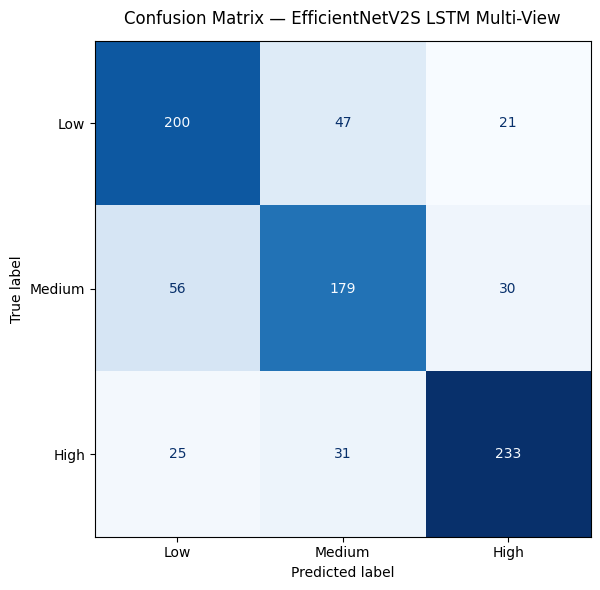

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds.take(steps["test"]):
    preds = model(images, training=False).numpy()
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(f"Total samples evaluated: {len(y_true)}")
print(f"Test accuracy: {np.mean(np.array(y_true) == np.array(y_pred)):.4f}")

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]   # readable class names
)
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)

ax.set_title("Confusion Matrix — EfficientNetV2S LSTM Multi-View", pad=12)
plt.tight_layout()
plt.savefig("confusion_matrix_lstm.png", dpi=150, bbox_inches="tight")
plt.show()